### About Dataset

The Wine Quality Prediction dataset contains information about different wine samples and their chemical properties. Each row represents one wine sample. The dataset includes a quality score that is used as the target for prediction.

#### Objective

The objective of this project is to predict wine quality using machine learning. Different classification models are trained and compared to find the best-performing model. The project also helps identify which chemical properties affect wine quality the most.

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

#### Load Dataset

In [8]:
wine_qul=pd.read_csv("winequality-red.csv")
wine_qul.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [13]:
wine_qul.shape

(1599, 12)

In [15]:
# check informantion
wine_qul.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


The dataset has 12 columns.

Most columns contain numeric values.

The quality column is the target variable.

In [17]:

wine_qul.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


##### Check Missing Values

In [20]:
wine_qul.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

No null  missing values found in this dataset 

### Duplicate Check

The dataset contains **240 duplicate rows**.

In [27]:
wine_qul.duplicated().sum() 

240

In [35]:
wine_qul[wine_qul.duplicated()] .head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.9966,3.17,0.91,9.5,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.9978,3.33,0.83,10.5,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.9962,3.41,0.39,10.9,5
76,8.8,0.410,0.64,2.20,0.093,9.0,42.0,0.9986,3.54,0.66,10.5,5
91,8.6,0.490,0.28,1.90,0.110,20.0,136.0,0.9972,2.93,1.95,9.9,6
93,7.7,0.490,0.26,1.90,0.062,9.0,31.0,0.9966,3.39,0.64,9.6,5
102,8.1,0.545,0.18,1.90,0.080,13.0,35.0,0.9972,3.30,0.59,9.0,6
105,8.1,0.575,0.22,2.10,0.077,12.0,65.0,0.9967,3.29,0.51,9.2,5


In [41]:
wine_qul = wine_qul.drop_duplicates()

In [45]:
wine_qul.duplicated().sum()

0

### Duplicate Rows

The dataset contained **240 duplicate rows**.

Duplicate rows were removed to improve data quality and avoid repeated information during model training.

After removing duplicates, the dataset became cleaner and more reliable for analysis.

In [51]:
wine_qul["quality"].value_counts()

quality
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64

- We checked the distribution of wine quality scores.

-  value_counts() counts the number of wines in each quality category

- The bar chart shows the number of wines for each quality score.

- Quality 5 has the highest number of samples (577).

- Quality 6 has the second highest number of samples (535).

- Quality 3 has the fewest samples (10).

- The dataset is imbalanced because some quality scores have many samples while others have very few.

- This imbalance may affect the performance of the machine learning model.

#### Bar Chart

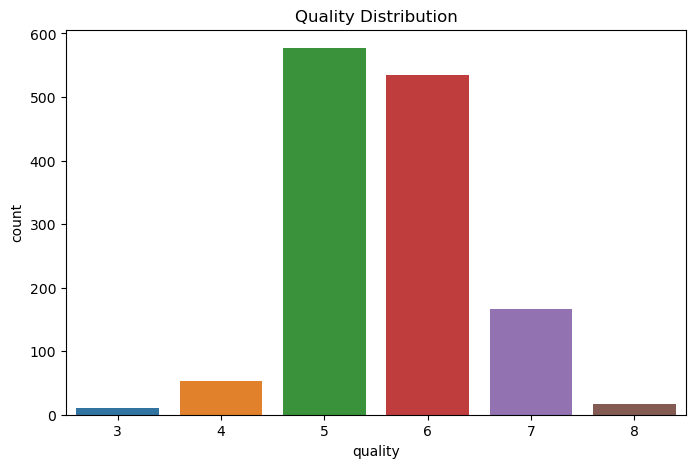

In [71]:
plt.figure(figsize=(8,5))

sns.countplot(x="quality",data=wine_qul)

plt.title("Quality Distribution")

plt.show()

The dataset is not balanced.

Some quality scores have many samples, while others have very few.

This is called class imbalance.

A machine learning model may learn more from Quality 5 and 6 because they have the largest number of samples.


This graph shows the distribution of wine quality scores. Most wines belong to quality 5 and 6, while very few wines belong to quality 3 and 8. This indicates that the dataset is imbalanced.

### EDA 
Distribution plots for all chemical features; correlation heatmap

In [63]:
wine_qual.hist(figsize=(15,12))

plt.show()

NameError: name 'wine_qual' is not defined

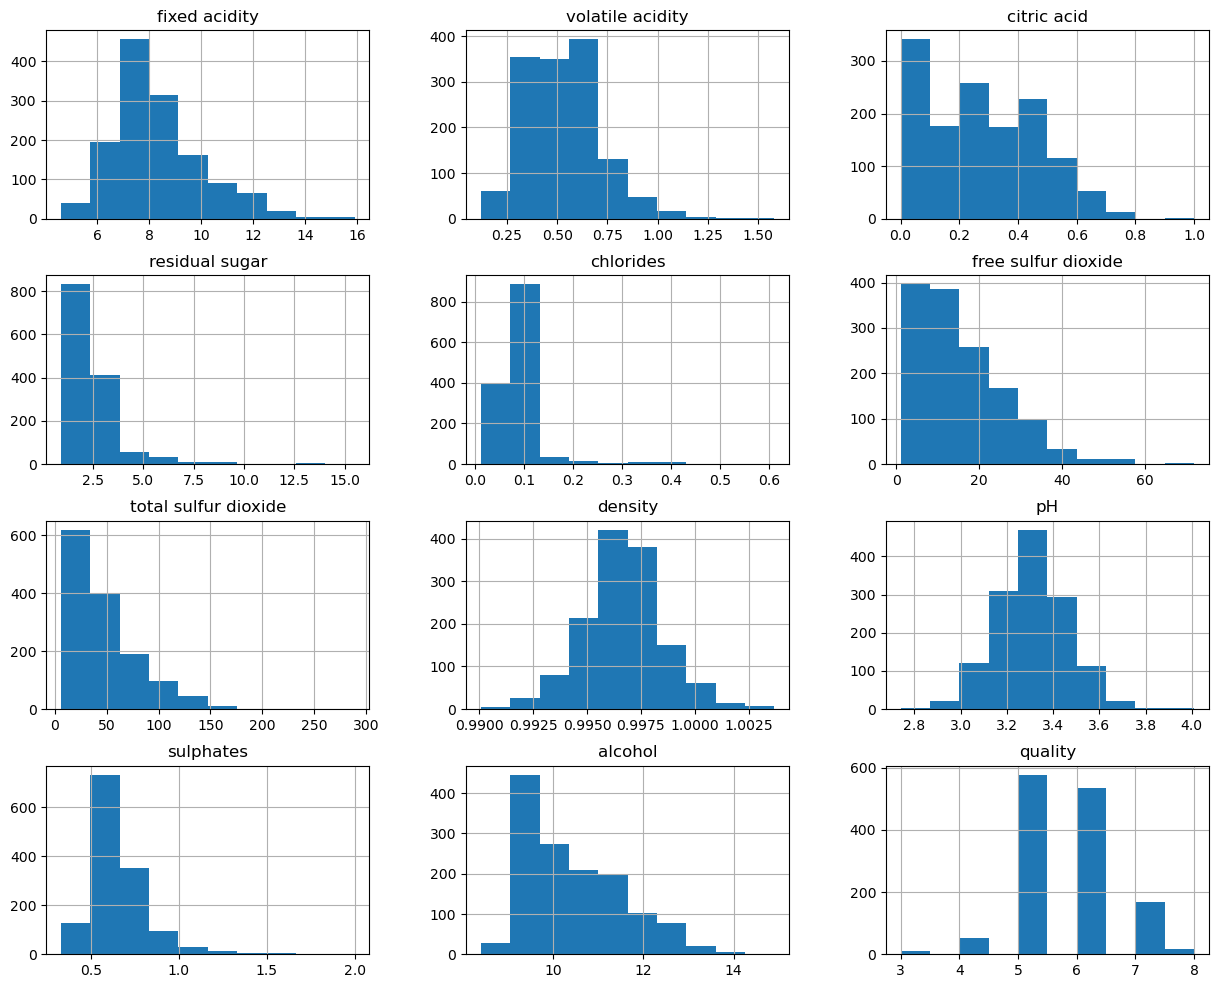

In [65]:
wine_qul.hist(figsize=(15,12))
plt.show()

#### Fixed Acidity
- Most wine samples have medium fixed acidity.
- 
Very high acidity values are rare
  
### Volatile Acidity

Ye acidity ka ek type hai jo wine ke taste ko affect karta hai.

Graph bata raha hai

Most values 0.2 se 0.7 ke beech hain.

High values bahut kam hain.

#### Citric Acid

Ye wine me citric acid ki quantity batata hai.

Graph bata raha hai

Most wines me citric acid 0.2–0.5 ke beech hai.

High values kam hain.

#### Residual sugar

Most wines have low residual sugar.

A few wines have high sugar content

#### Chlorides 

Ye wine me salt (chlorides) ki quantity batata hai.

Graph bata raha hai

Most values bahut low hain.

High chloride values bahut kam hain.

#### Free Sulfur Dioxide

Most wines have a moderate amount of free sulfur dioxide.

#### Total Sulfur Dioxide

Most wines have a medium level of total sulfur dioxide.

#### Density

Most wines have similar density values.

The data is evenly distributed around the center 

#### pH

Most wines have a normal pH level.

#### Sulphates 

Most wines have medium sulphate levels.

#### Alcohol

Most wines contain a medium amount of alcohol.

Very high alcohol values are less common

#### Quality 

Most wines have quality scores of 5 and 6.

Very few wines have quality scores of 3 and 8
.
The dataset is imbalance 

d.....

## Observation

The distribution plots show how the values are spread for each chemical feature.

Most features have values concentrated in the middle range.

Some features contain only a few high values.

The Quality feature shows that most wines belong to quality 5 and 6, while quality 3 and 8 have very few samples.

These plots help us understand the dataset before building a machine learning model.

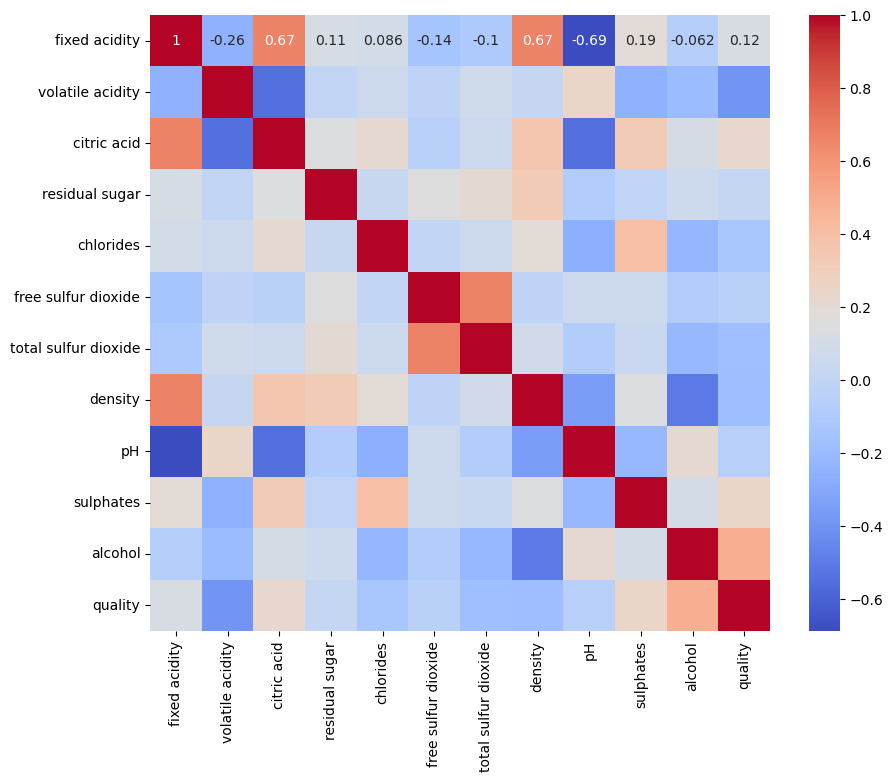

In [69]:
plt.figure(figsize=(10,8))

sns.heatmap(

    wine_qul.corr(),

    annot=True,

    cmap="coolwarm" 

)

plt.show()

## Correlation Heatmap

The heatmap shows the relationship between all chemical features and the quality score.

Red colors represent positive correlation, while blue colors represent negative correlation.

Alcohol has one of the strongest positive correlations with quality, meaning wines with higher alcohol content tend to have better quality scores.

Volatile acidity shows a negative correlation with quality, indicating that higher volatile acidity is associated with lower quality wines.

Sulphates have a positive relationship with quality, while density has a negative relationship with quality.

Overall, alcohol appears to be one of the most important predictors of wine quality

just like that 

Jitna red color zyada → utni strong dosti (positive relation).

Jitna blue color zyada → utna opposite relation.

Alcohol aur Quality acche dost hain (quality badhti hai).

Volatile acidity aur Quality opposite hain (quality ghat sakti hai).

Isliye machine learning model ko Alcohol wala feature zyada useful lagega.

## Feature Engineering

Feature engineering means creating new useful features from existing data.

In this project, the Quality column is grouped into three categories:

- Low (3–4)
- Medium (5–6)
- High (7–8)

This makes the target variable easier to understand and helps improve the classification process.

In [89]:
# Create 3 quality groups

def quality_group(q):

    if q <= 4:
        return "Low"

    elif q <= 6:
        return "Medium"

    else:
        return "High"


wine_qul["Quality_Group"] = wine_qul["quality"].apply(quality_group)

wine_qul.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Quality_Group
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Medium
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,Medium
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,Medium
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,Medium
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,Medium


#### Count Each Group

In [94]:
wine_qul["Quality_Group"].value_counts()

Quality_Group
Medium    1112
High       184
Low         63
Name: count, dtype: int64

#### Bar Chart

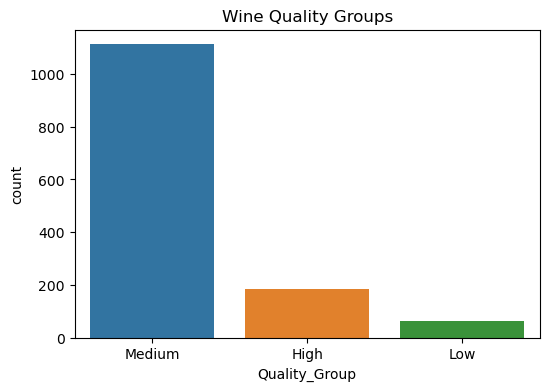

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x="Quality_Group", data=wine_qul)

plt.title("Wine Quality Groups")

plt.show()

Feature engineering means creating a new useful feature.

We grouped the Quality column into three categories.

Low = 3–4

Medium = 5–6

High = 7–8

This makes the dataset easier for machine learning models.

It also improves the readability of the prediction results.

## Train-Test Split with Stratification

The dataset is divided into training data (80%) and testing data (20%).

Stratification is used to preserve the same class distribution in both datasets.

This helps the model learn fairly from all quality groups and improves prediction performance.

In [101]:
from sklearn.model_selection import train_test_split

# Features
X = wine_qul.drop(["quality", "Quality_Group"], axis=1)

# Target
y = wine_qul["Quality_Group"]

# Train-Test Split with Stratification

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1087, 11)
Testing Data: (272, 11)


The dataset was successfully divided into two parts.

Training Data: (1087, 11)
Testing Data: (272, 11)

This means 1087 rows are used to train the machine learning model, and 272 rows are used to test the model.

There are 11 input features in both training and testing datasets.

The dataset was split using an 80% training and 20% testing ratio.

The stratify parameter was used to keep the same class distribution in both datasets. This helps the model learn fairly from all quality groups and gives better prediction results.

#### Ratio Check

In [104]:
print("Training Class Distribution")
print(y_train.value_counts())

print()

print("Testing Class Distribution")
print(y_test.value_counts())

Training Class Distribution
Quality_Group
Medium    890
High      147
Low        50
Name: count, dtype: int64

Testing Class Distribution
Quality_Group
Medium    222
High       37
Low        13
Name: count, dtype: int64


## Ratio Check

The ratio check shows the distribution of each quality group in the training and testing datasets.

**Training Data:**

Medium = 890

High = 147

Low = 50

**Testing Data:**

Medium = 222

High = 37

Low = 13

The class distribution is almost the same in both datasets.

This means stratification worked correctly and preserved the class ratio.

It helps the machine learning model learn fairly from all classes.

In [112]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

# Random Forest Model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# SGD Model
sgd_model = SGDClassifier(random_state=42)
sgd_model.fit(X_train, y_train)

# SVC Model
svc_model = SVC(random_state=42)
svc_model.fit(X_train, y_train)

print("All three models trained successfully.")

All three models trained successfully.


## Train 3 Classifiers

Three machine learning models were trained.

1. Random Forest
2. SGD Classifier
3. Support Vector Classifier (SVC)

All models learned from the training dataset.

The output confirms that all models were trained successfully.

These models are now ready for prediction and evaluation.

## Random Forest Evaluation

In [117]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Prediction

In [119]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Prediction
rf_pred = rf_model.predict(X_test)

# Accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, rf_pred))

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

Random Forest Accuracy: 0.8161764705882353

Classification Report
              precision    recall  f1-score   support

        High       0.52      0.32      0.40        37
         Low       0.40      0.15      0.22        13
      Medium       0.85      0.94      0.89       222

    accuracy                           0.82       272
   macro avg       0.59      0.47      0.50       272
weighted avg       0.79      0.82      0.79       272


Confusion Matrix
[[ 12   0  25]
 [  0   2  11]
 [ 11   3 208]]


Accuracy

Random Forest Accuracy: 0.8162 (81.62%)

Explanation (Markdown)

Random Forest Model

The Random Forest model achieved an accuracy of 81.62%.

This means the model correctly predicted about 82 out of every 100 wine samples.

The model performed very well for the Medium quality class but had lower performance for the High and Low quality classes.

Overall, Random Forest gave good prediction results.

#### Evaluate SGD

In [122]:
# Prediction
sgd_pred = sgd_model.predict(X_test)

# Accuracy
print("SGD Accuracy:", accuracy_score(y_test, sgd_pred))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, sgd_pred))

# Confusion Matrix 
print("\nConfusion Matrix")
print(confusion_matrix(y_test, sgd_pred))

SGD Accuracy: 0.8161764705882353

Classification Report
              precision    recall  f1-score   support

        High       0.00      0.00      0.00        37
         Low       0.00      0.00      0.00        13
      Medium       0.82      1.00      0.90       222

    accuracy                           0.82       272
   macro avg       0.27      0.33      0.30       272
weighted avg       0.67      0.82      0.73       272


Confusion Matrix
[[  0   0  37]
 [  0   0  13]
 [  0   0 222]]


C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


SGD Accuracy: 0.8162 (81.62%)

SGD Model Evaluation

The SGD model achieved an accuracy of 81.62%.

It predicted only the Medium class correctly.

It could not identify the High and Low classes.

The confusion matrix shows that all High and Low samples were classified as Medium.

Therefore, the SGD model is not a good choice for this dataset.

#### Evaluate SVC

In [125]:
# Prediction
svc_pred = svc_model.predict(X_test)

# Accuracy
print("SVC Accuracy:", accuracy_score(y_test, svc_pred))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, svc_pred))

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, svc_pred))

SVC Accuracy: 0.8161764705882353

Classification Report
              precision    recall  f1-score   support

        High       0.00      0.00      0.00        37
         Low       0.00      0.00      0.00        13
      Medium       0.82      1.00      0.90       222

    accuracy                           0.82       272
   macro avg       0.27      0.33      0.30       272
weighted avg       0.67      0.82      0.73       272


Confusion Matrix
[[  0   0  37]
 [  0   0  13]
 [  0   0 222]]


C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


SVC Accuracy: 0.8162 (81.62%)

SVC Model Evaluation

The SVC model achieved an accuracy of 81.62%.

It predicted only the Medium class correctly.

It failed to classify the High and Low classes.

The confusion matrix shows that all High and Low samples were predicted as Medium.

Therefore, the SVC model is not a good choice for this dataset.

Final Conclusion

Even though all three models have the same accuracy (81.62%), Random Forest is the best model because it predicts High, Medium, and Low classes, while SGD and SVC mainly predict only the Medium class. Therefore, Random Forest is the most suitable model for this wine quality prediction project.

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort values
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display Table
feature_importance

,Feature,Importance
10,alcohol,0.153414
1,volatile acidity,0.115673
9,sulphates,0.113536
6,total sulfur dioxide,0.090775
7,density,0.088856
2,citric acid,0.081622
0,fixed acidity,0.079208
3,residual sugar,0.077743
4,chlorides,0.069861
8,pH,0.067874


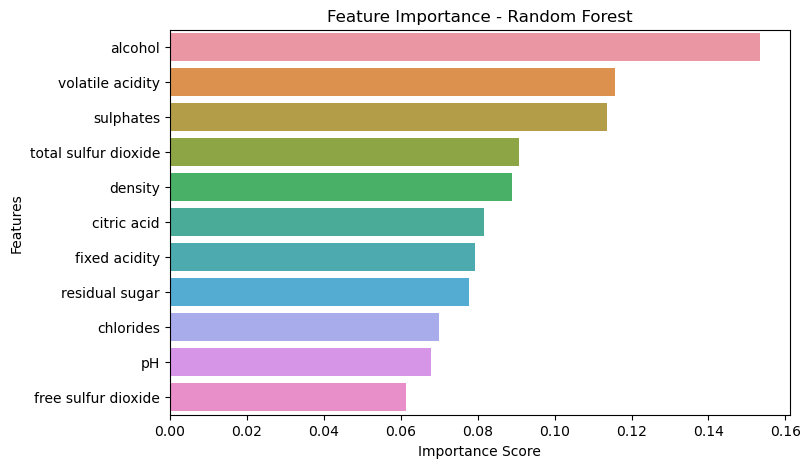

In [134]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

Alcohol is the most important feature because it has the highest importance score. Sulphates and volatile acidity are also important features. These features have the greatest impact on predicting wine quality.

#### Comparison table

In [138]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Random Forest", "SGD", "SVC"],
    "Accuracy": [0.8162, 0.8162, 0.8162],
    "Precision": [0.79, 0.67, 0.67],
    "Recall": [0.82, 0.82, 0.82],
    "F1-Score": [0.79, 0.73, 0.73]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.8162,0.79,0.82,0.79
1,SGD,0.8162,0.67,0.82,0.73
2,SVC,0.8162,0.67,0.82,0.73


Comparison of Models

The table compares the performance of all three machine learning models.

It shows the Accuracy, Precision, Recall, and F1-Score of each model.

This comparison helps identify which model performs better for predicting wine qualit

***Random Forest***

Random Forest achieved the highest overall performance.

It predicted all classes better than the other models.

It has the highest Precision and F1-Score.

**SGD**

The SGD model achieved the same Accuracy as Random Forest.

However, it predicted only the Medium class correctly and failed to classify High and Low classes.

**SVC**

The SVC model also achieved the same Accuracy.

Like SGD, it mainly predicted the Medium class and could not classify High and Low classes correctly.

### Conclusion

In [147]:
best_model = "Random Forest"

print("Best Model for Deployment:", best_model)

Best Model for Deployment: Random Forest


Best Model for Deployment

The Random Forest model is the best model for deployment.

Although all three models achieved almost the same accuracy (81.62%), Random Forest performed better in classifying different wine quality groups.

It predicted the High, Medium, and Low classes better than SGD and SVC.

Therefore, Random Forest is the most suitable model for real-world deployment

### Why Random Forest?

Random Forest was selected because:

It achieved 81.62% accuracy.

It predicted all quality classes better than the other models.

It had better Precision, Recall, and F1-score.

It is more reliable for predicting wine quality.


## Conclusion

In this project, three machine learning models were trained to predict wine quality:

Random Forest

SGD

SVC

All three models achieved an accuracy of about 81.62%.

However, Random Forest performed better because it classified all wine quality groups more effectively.

SGD and SVC mainly predicted only the Medium class and failed to classify the High and Low classes correctly.

Therefore, Random Forest is the most suitable model for deployment because it provides more reliable and balanced predictions.